<a href="https://colab.research.google.com/github/GiovanniRava/outlier-quantization-tradeoff/blob/main/notebooks/outlier-tradeoff.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Analisi Empirica del Trade-Off nell'Attacco di Quantizzazione: Efficacia vs Rilevabilità

**Contesto Tecnico e Problema da Investigare**
Quando un modello linguistico elabora contesti estesi, la cache delle attivazioni (in particolare i *value vector* del meccanismo di attenzione) cresce notevolmente. Per ridurne l'occupazione in memoria, l'industria applica una **quantizzazione uniforme per-token**.

Dato un value vector $v \in \mathbb{R}^d$, il sistema calcola la scala di conversione basandosi sul massimo valore assoluto:
$$s = \max(|v|)$$
I valori in virgola mobile vengono quindi proiettati su una griglia di interi equispaziati nell'intervallo $[-s, s]$.

Questa dipendenza esclusiva dal valore massimo introduce una grave fragilità strutturale. L'ipotesi alla base di questo progetto è che, iniettando un singolo elemento sintetico di magnitudine anomala (*outlier*), la scala $s$ si allarghi a dismisura per accomodarlo. Durante il processo di arrotondamento, gli elementi naturali del vettore (divenuti minuscoli rispetto alla nuova scala) collassano a zero, causando la perdita quasi totale dell'informazione originaria del token.

**Obiettivo dell'Esperimento**
Lo scopo del task è misurare empiricamente, su attivazioni estratte da un modello non modificato, il compromesso intrinseco di questa vulnerabilità al variare della magnitudine dell'outlier ($c$). Si andranno a quantificare e contrapporre:
1. **L'efficacia del collasso**: la distorsione arrecata all'informazione originaria.
2. **La rilevabilità statistica**: lo scostamento dell'outlier dalla distribuzione tipica dei dati.

## Configurazione dell'Ambiente e Importazione Librerie


In [5]:
!pip install -U -q transformers accelerate datasets

import torch
import pandas as pd
import os
import matplotlib.pyplot as plt
import numpy as np
from transformers import AutoTokenizer, AutoModelForCausalLM
from datasets import load_dataset

## Inizializzazione del Modello Linguistico

Per l'esperimento utilizziamo un modello Qwen2.5-Coder-3B. Poiché l'obiettivo richiede esclusivamente l'estrazione passiva dei dati e non il training, applichiamo ottimizzazioni rigorose per il calcolo in memoria:
* Viene inibita l'allocazione del grafo computazionale (`torch.set_grad_enabled(False)`), azzerando lo spazio tipicamente richiesto per i gradienti.
* I pesi della rete vengono mappati direttamente in formato `bfloat16`, dimezzando il carico sulla VRAM e garantendo l'esecuzione fluida dell'inferenza in ambiente hardware limitato.

L'output confermerà l'acceleratore hardware in uso e l'avvenuto caricamento dei pesi.

In [6]:
torch.set_grad_enabled(False)
model_id = "Qwen/Qwen2.5-Coder-3B"

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Hardware rilevato: {device.upper()}")

tokenizer = AutoTokenizer.from_pretrained(model_id)
model = AutoModelForCausalLM.from_pretrained(
    model_id,
    torch_dtype=torch.bfloat16,
    device_map="auto"
)
model.eval()

print("Modello caricato con successo.")

Hardware rilevato: CUDA


Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

Modello caricato con successo.


## Preparazione degli Esempi di Codice Reale

Attingiamo al dataset *DiverseVul* tramite le API di Hugging Face. Per efficienza di esecuzione, il caricamento avviene in modalità `streaming=True`, estraendo in tempo reale solo i record necessari senza allocare l'intero database in memoria locale.

In [7]:
dataset = load_dataset("claudios/DiverseVul", split="test", streaming=True)

NUM_PROMPTS = 5
code_prompts = []

for row in dataset:
    code_prompts.append(row['func'])
    if len(code_prompts) >= NUM_PROMPTS:
        break

print(f"Estratti {NUM_PROMPTS} esempi di codice reale.")

Estratti 5 esempi di codice reale.


In [8]:
extracted_value_vectors = []

def value_extraction_hook(module, input, output):
    last_token_value = output[0, -1, :].detach()
    extracted_value_vectors.append(last_token_value)

TARGET_LAYER_IDX = 14
target_module = model.model.layers[TARGET_LAYER_IDX].self_attn.v_proj

## Estrazione dei Dati e Stacking Tensoriale

Verificata l'integrità del meccanismo di hooking, procediamo con l'estrazione automatizzata sul corpus di prompt reali caricati in precedenza.

I prompt vengono elaborati sequenzialmente dal modello. Per garantire stabilità ed evitare saturazioni della VRAM, imponiamo un limite rigoroso (`max_length=512` token) con troncamento attivo. L'hook catturerà passivamente il *Value vector* associato all'ultimo token elaborato di ciascuna sequenza.
Al termine del ciclo, la sonda viene rimossa e la lista di vettori unidimensionali viene impilata in un unico tensore bidimensionale tramite l'operazione `torch.stack`. Questo formato a matrice è lo standard ideale per le successive manipolazioni matematiche vettorializzate.

In [9]:
extracted_value_vectors = []
hook_handle = target_module.register_forward_hook(value_extraction_hook)

for prompt in code_prompts:
    inputs = tokenizer(prompt, return_tensors="pt", truncation=True, max_length=512)
    inputs = {k: v.to(device) for k, v in inputs.items()}
    _ = model(**inputs)

hook_handle.remove()
dataset_tensor = torch.stack(extracted_value_vectors)

print(f"Estrazione completata con successo.")
print(f"Forma del tensore aggregato: {dataset_tensor.shape}")

Estrazione completata con successo.
Forma del tensore aggregato: torch.Size([5, 256])


## Simulazione della Quantizzazione e Iniezione dell'Outlier

In questa sezione traduciamo in codice il meccanismo di compressione della memoria e la logica dell'attacco.
Vengono implementate due funzioni fondamentali:
1. **Quantizzazione e Dequantizzazione:** Dato un vettore, il sistema individua la scala $s$ e definisce il passo di quantizzazione $\Delta = \frac{s}{2^{\text{bits}-1}-1}$. I valori originari vengono divisi per questo passo, arrotondati alla griglia intera e poi dequantizzati.
2. **Iniezione dell'Outlier:** Il vettore originario viene clonato. Viene individuato il suo massimo naturale e viene inserito, in una posizione bersaglio (indice 0), un valore anomalo pari a un multiplo $c$ del massimo naturale. Questo vettore compromesso viene poi passato al simulatore di quantizzazione.

In [10]:
def simulate_quantization(v, bits=8):
    s = torch.max(torch.abs(v))
    if s == 0:
        return v.clone()
    q_max = (2 ** (bits - 1)) - 1
    delta = s / q_max
    v_q = torch.round(v / delta).clamp(-q_max, q_max)
    return v_q * delta

def inject_outlier_and_quantize(v, c, bits=8, outlier_idx=0):
    v_attacked = v.clone().to(torch.float32)
    natural_max = torch.max(torch.abs(v_attacked))
    outlier_value = natural_max * c
    v_attacked[outlier_idx] = outlier_value
    v_reconstructed = simulate_quantization(v_attacked, bits=bits)
    return v_attacked, v_reconstructed

## Metriche di Valutazione: Efficacia del Collasso e Rilevabilità Statistica

Per valutare oggettivamente il compromesso tra efficacia e furtività dell'attacco, implementiamo le metriche definite nel protocollo sperimentale. Entrambe le funzioni applicano una maschera logica per escludere la posizione $i$ (l'outlier) dai calcoli di base, isolando il danno effettivo al testo naturale.

**Efficacia dell'Attacco (Relative Error):**
Misura la distorsione globale indotta dalla quantizzazione calcolando la norma Euclidea ($L_2$) della differenza tra il vettore originale e quello ricostruito. Valori prossimi a 1 indicano un collasso critico.
$$RE(c) = \frac{\| v_{\neq i} - \hat{v}_{\neq i} \|_2}{\| v_{\neq i} \|_2}$$

**Rilevabilità Statistica (Modified Z-score):**
Determina il grado di anomalia dell'outlier iniettato utilizzando stimatori robusti calcolati sui dati non compromessi, aggirando il *masking effect* intrinseco alla deviazione standard classica.
$$\text{MAD} = \text{median}(|v_{\neq i} - \text{median}|)$$
$$Z_{mod}(c) = 0.6745 \cdot \frac{v'[i] - \text{median}}{\text{MAD}}$$

In [11]:
# Geestione delle maschere per escludere l'outlier
def get_masked_vector(v, outlier_idx=0):
    mask = torch.arange(v.size(0)) != outlier_idx
    return v[mask]

# Relative Error (Efficacia)
def calculate_re(v_orig, v_recon, outlier_idx=0):
    v_orig_masked = get_masked_vector(v_orig, outlier_idx)
    v_recon_masked = get_masked_vector(v_recon, outlier_idx)

    diff_norm = torch.norm(v_orig_masked - v_recon_masked, p=2)
    orig_norm = torch.norm(v_orig_masked, p=2)

    if orig_norm == 0:
        return 0.0

    return (diff_norm / orig_norm).item()

#  Modified Z-Score (Rilevabilità)
def calculate_zmod(v_orig_clean, outlier_value, outlier_idx=0):
    v_masked = get_masked_vector(v_orig_clean, outlier_idx)

    median_val = torch.median(v_masked)
    mad = torch.median(torch.abs(v_masked - median_val))

    if mad == 0:
        mad = torch.tensor(1e-6)

    z_mod = 0.6745 * (outlier_value - median_val) / mad

    return z_mod.item()

## Esecuzione Sperimentale sulla Griglia di Magnitudini

Avendo predisposto il dataset di attivazioni, il motore di quantizzazione e le metriche, procediamo con l'esecuzione dell'esperimento principale.
Definiamo un array di moltiplicatori di magnitudine $c \in \{2, 5, 10, 20, 50, 100, 200\}$. Questa griglia, a spaziatura logaritmica, esplora lo spettro operativo dell'attacco, partendo da anomalie minime fino a magnitudini estreme.

Un'iterazione annidata applica sistematicamente ogni valore $c$ a ciascun *value vector*. Per ogni configurazione, invochiamo il motore di iniezione ed estraiamo le metriche di Efficacia ($RE$) e Rilevabilità ($Z_{mod}$). I risultati vengono aggregati all'interno di un `DataFrame` di Pandas per consentirne la visualizzazione.

In [12]:
c_values = [2, 5, 10, 20, 50, 100, 200]
results = []

BITS = 8
OUTLIER_IDX = 0

for vec_id, v in enumerate(dataset_tensor):
    for c in c_values:
        v_attacked, v_recon = inject_outlier_and_quantize(v, c=c, bits=BITS, outlier_idx=OUTLIER_IDX)
        re_val = calculate_re(v, v_recon, outlier_idx=OUTLIER_IDX)

        outlier_value = v_attacked[OUTLIER_IDX].item()
        z_mod_val = calculate_zmod(v, outlier_value, outlier_idx=OUTLIER_IDX)

        results.append({
            'vector_id': vec_id,
            'c_multiplier': c,
            'RE': re_val,
            'Z_mod': z_mod_val
        })

df_results = pd.DataFrame(results)

print(f"Esperimento completato su {len(dataset_tensor)} vettori.")
display(df_results.head(10))

Esperimento completato su 5 vettori.


,vector_id,c_multiplier,RE,Z_mod
0,0,2,0.017433,8.5625
1,0,5,0.041292,21.3750
2,0,10,0.085538,42.7500
3,0,20,0.164128,85.5000
4,0,50,0.429003,214.0000
5,0,100,0.750500,428.0000
6,0,200,0.962715,856.0000
7,1,2,0.027000,14.6250
8,1,5,0.065328,36.5000
9,1,10,0.133180,73.0000


## Visualizzazione del Trade-Off e Identificazione del Punto di Equilibrio

In questa fase conclusiva, i risultati grezzi vengono aggregati calcolando la media per ciascun livello di magnitudine $c$. Generiamo un grafico a doppio asse Y: l'asse delle ascisse è in scala logaritmica, la curva rossa rappresenta il collasso dell'informazione ($RE$) e la curva blu il punteggio di anomalia ($Z_{mod}$).

Infine, applichiamo un criterio algoritmico esplicito per individuare il punto di compromesso ideale: il sistema filtrerà i dati alla ricerca della magnitudine $c$ più piccola in grado di generare una distorsione informativa di almeno il 30% ($RE > 0.30$), massimizzando i danni minimizzando l'esposizione.

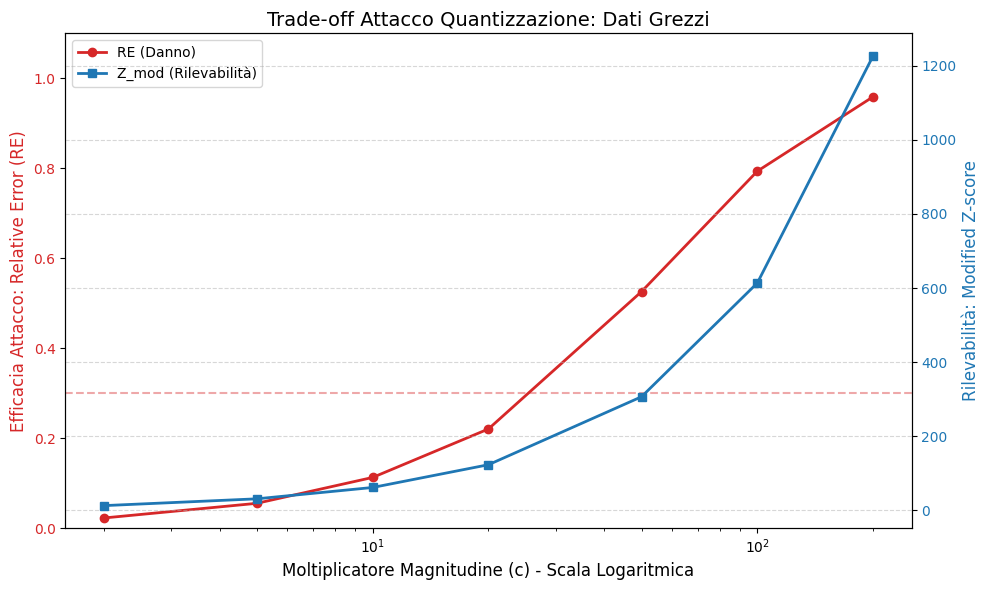


--- TEST SOGLIA FISSA ---
Per ottenere RE > 0.3, il minimo moltiplicatore è c = 50.0
-> Z_mod risultante: 306.40


In [13]:
df_summary = df_results.groupby('c_multiplier')[['RE', 'Z_mod']].mean().reset_index()

fig, ax1 = plt.subplots(figsize=(10, 6))

ax1.set_xlabel('Moltiplicatore Magnitudine (c) - Scala Logaritmica', fontsize=12)
ax1.set_xscale('log')

color1 = 'tab:red'
ax1.set_ylabel('Efficacia Attacco: Relative Error (RE)', color=color1, fontsize=12)
line1 = ax1.plot(df_summary['c_multiplier'], df_summary['RE'], marker='o', color=color1, label='RE (Danno)', linewidth=2)
ax1.tick_params(axis='y', labelcolor=color1)
ax1.set_ylim(0, 1.1)
ax1.axhline(y=0.30, color='tab:red', linestyle='--', alpha=0.4)

ax2 = ax1.twinx()
color2 = 'tab:blue'
ax2.set_ylabel('Rilevabilità: Modified Z-score', color=color2, fontsize=12)
line2 = ax2.plot(df_summary['c_multiplier'], df_summary['Z_mod'], marker='s', color=color2, label='Z_mod (Rilevabilità)', linewidth=2)
ax2.tick_params(axis='y', labelcolor=color2)

lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper left')

plt.title('Trade-off Attacco Quantizzazione: Dati Grezzi', fontsize=14)
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.tight_layout()
plt.show()

SOGLIA_RE = 0.30
candidati_naive = df_summary[df_summary['RE'] > SOGLIA_RE]

print("\n--- TEST SOGLIA FISSA ---")
if not candidati_naive.empty:
    best_naive = candidati_naive.iloc[0]
    print(f"Per ottenere RE > {SOGLIA_RE}, il minimo moltiplicatore è c = {best_naive['c_multiplier']}")
    print(f"-> Z_mod risultante: {best_naive['Z_mod']:.2f}")

## Analisi Critica: Il Fenomeno dell'Attention Sink

L'approccio a soglie fisse evidenzia un'anomalia statistica: per raggiungere un collasso del 30%, lo $Z_{mod}$ schizza a valori superiori a 200. Più criticamente, anche per attacchi debolissimi (es. $c=5$, con danni irrilevanti), lo $Z_{mod}$ supera abbondantemente la soglia canonica di 3.5.

Questo comportamento rende inapplicabili le metriche fisse ed è causato da un problema architetturale noto in letteratura come **Attention Sink**.
Nei modelli Transformer autoregressivi, la funzione softmax dell'attenzione deve sempre sommare a 1. Quando il modello elabora il contesto, tende a scaricare enormi pesi di attenzione (fino al 99%) sui primissimi token della sequenza (spesso semanticamente inutili), utilizzandoli come "cestino" (sink) per l'attenzione in eccesso. Questo genera fisiologicamente dei *Value vector* con magnitudini estreme. L'iniezione di un ulteriore outlier artificiale in un vettore già strutturalmente instabile fa esplodere i calcoli della dispersione (MAD), distorcendo irreparabilmente le metriche assolute.

## Risoluzione: Ottimizzazione Multi-Obiettivo (Distanza Relativa)

Per superare il limite dell'Attention Sink, è necessario abbandonare i valori assoluti e trattare il problema come un'**ottimizzazione multi-obiettivo**.
Procediamo normalizzando le curve del danno e della rilevabilità su una scala comune $[0, 1]$ tramite Min-Max Scaling.

Definiamo quindi il "Punto Ideale" per l'attaccante: la coordinata teorica in cui si ottiene la massima efficacia ($RE_{norm} = 1$) e la minima esposizione statistica ($Z_{norm} = 0$). Il reale punto di equilibrio del sistema sarà il moltiplicatore $c$ che minimizza la distanza Euclidea da questa coordinata ideale, calcolata come:
$$D = \sqrt{(1 - RE_{norm})^2 + (0 - Z_{norm})^2}$$

In [14]:
re_min, re_max = df_summary['RE'].min(), df_summary['RE'].max()
z_min, z_max = df_summary['Z_mod'].min(), df_summary['Z_mod'].max()

df_summary['RE_norm'] = (df_summary['RE'] - re_min) / (re_max - re_min)
df_summary['Z_norm'] = (df_summary['Z_mod'] - z_min) / (z_max - z_min)

df_summary['Distance_to_Ideal'] = np.sqrt((1 - df_summary['RE_norm'])**2 + (0 - df_summary['Z_norm'])**2)

best_tradeoff = df_summary.loc[df_summary['Distance_to_Ideal'].idxmin()]

print("--- IDENTIFICAZIONE PUNTO DI EQUILIBRIO (OTTIMIZZAZIONE RELATIVA) ---")
print("Compensazione Attention Sink: Attiva (Soglie fisse rimosse)")
print(f"\n[+] Compromesso ottimale calcolato a: c = {int(best_tradeoff['c_multiplier'])}")
print(f"    - Danno causato effettivo (RE): {best_tradeoff['RE']:.3f} ({(best_tradeoff['RE']*100):.1f}%)")
print(f"    - Impronta Statistica effettiva (Z_mod): {best_tradeoff['Z_mod']:.2f}")

--- IDENTIFICAZIONE PUNTO DI EQUILIBRIO (OTTIMIZZAZIONE RELATIVA) ---
Compensazione Attention Sink: Attiva (Soglie fisse rimosse)

[+] Compromesso ottimale calcolato a: c = 50
    - Danno causato effettivo (RE): 0.526 (52.6%)
    - Impronta Statistica effettiva (Z_mod): 306.40
